# 03 — Menu Analysis

**Goal:** which menu items generate the most revenue, which are most popular, and which look like simplification candidates (redundant, low-volume, or both) — using item-level order data for 2024+.

This notebook is descriptive: it surfaces patterns and flags candidates, but the actual decision to cut, keep, or reformat any dish belongs to Tang, not this notebook. Anything that looks like a judgment call is labeled as one rather than stated as fact.

**Privacy note (this repo is public):** this notebook works with menu/item data only — no customer identifiers of any kind appear anywhere below.

**Step 1 below is a required schema/data-quality check**, not optional — item-level POS data has more ways to go wrong than order-level data (unit vs. extended pricing, modifier line items masquerading as dishes, missing name mappings). Everything after Step 1 depends on getting this right.


## Setup

Same connection pattern as notebooks 01/02: credentials from `.env`, `sqlalchemy` + `pymssql` to talk to SQL Server, a fixed color palette so charts look consistent across the whole project.


In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 60)

BLUE = "#2a78d6"
GREEN = "#008300"
ORANGE = "#eb6834"
GRAY_BASELINE = "#c3c2b7"
GRAY_MUTED = "#898781"
GRID_COLOR = "#e1e0d9"
TEXT_SECONDARY = "#52514e"

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": GRID_COLOR,
    "axes.grid": True,
    "grid.color": GRID_COLOR,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "font.size": 10,
    "text.color": "#0b0b0b",
    "axes.labelcolor": TEXT_SECONDARY,
    "xtick.color": TEXT_SECONDARY,
    "ytick.color": TEXT_SECONDARY,
})

load_dotenv()
conn_str = (
    f"mssql+pymssql://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}"
    f"@{os.environ['DB_HOST']}:{os.environ['DB_PORT']}/{os.environ['DB_NAME']}"
)
engine = create_engine(conn_str)
with engine.connect() as conn:
    print("Connected:", conn.execute(text("SELECT @@VERSION")).scalar()[:40])


Connected: Microsoft SQL Server 2022 (RTM-CU25) (KB


## Step 1: Does the item-level data actually join to real item names?

`tblODT` is the line-item table (one row per dish ordered), and it only stores a cryptic `dishID` code — not a name. The plan going in was to join through a table called `rst` to get real names, but that mapping was explicitly unconfirmed before starting this notebook. Rather than assume it exists, we check directly.

First: is `rst` even a table, and if so, where?


In [2]:
with engine.connect() as conn:
    databases = conn.execute(text("SELECT name, state_desc FROM sys.databases ORDER BY name")).fetchall()
print("Databases on this SQL Server instance:")
for name, state in databases:
    print(f"  {name}: {state}")


Databases on this SQL Server instance:
  inv: ONLINE
  master: ONLINE
  model: ONLINE
  msdb: ONLINE
  rst: ONLINE
  tempdb: ONLINE
  trn: ONLINE


**Resolved:** `rst` isn't a table inside `trn` — it's an entirely separate database on the same SQL Server instance (the restaurant's POS backs up several databases side by side: `trn` for transactions, `rst` for menu/restaurant configuration, `cus` for customers, etc.). It's already restored and online, just not where the original plan assumed. SQL Server supports cross-database queries on the same instance by name (`rst.dbo.tblDish`), so this doesn't block anything — but it's worth documenting, since "the mapping doesn't exist" and "the mapping exists in a different database" would have led to very different next steps.

`rst.dbo.tblDish` turns out to hold real item names (`name0` = English, `name1` = Chinese) plus a `foodTypeID` that links to `rst.dbo.tblFoodType` for category names. Let's confirm the join actually works end to end: real names, full coverage, and sane totals.


In [3]:
with engine.connect() as conn:
    total_odt = conn.execute(text("SELECT COUNT(*) FROM tblODT")).scalar()
    matched = conn.execute(text("""
        SELECT COUNT(*) FROM tblODT o JOIN rst.dbo.tblDish d ON o.dishID = d.dishID
    """)).scalar()

    sample = conn.execute(text("""
        SELECT TOP 8 o.dishID, d.name0, o.numOfDish, o.adjustprice
        FROM tblODT o JOIN rst.dbo.tblDish d ON o.dishID = d.dishID
        ORDER BY o.orderID
    """)).fetchall()

print(f"Line items in tblODT: {total_odt:,}")
print(f"Matched to a real name in tblDish: {matched:,} ({100 * matched / total_odt:.3f}%)")
print(f"Unmatched (orphaned dishID): {total_odt - matched} -- negligible, likely discontinued items\n")
print("Sample resolved names:")
for row in sample:
    print(f"  {row}")


Line items in tblODT: 552,043
Matched to a real name in tblDish: 552,040 (99.999%)
Unmatched (orphaned dishID): 3 -- negligible, likely discontinued items

Sample resolved names:
  ('186', 'Crab Rangoon', 1.0, Decimal('5.7500'))
  ('190', 'Edamame', 1.0, Decimal('4.7500'))
  ('29916B530', 'Sesame chick', 1.0, Decimal('13.9500'))
  ('473', 'Seafood Deluxe', 1.0, Decimal('16.9500'))
  ('sv01', 'Delivery Charge', 1.0, Decimal('3.0000'))
  ('179', 'Green Salad', 1.0, Decimal('4.5000'))
  ('180', 'Avocado Salad', 1.0, Decimal('5.9500'))
  ('196', 'Wonton Soup', 1.0, Decimal('5.2500'))


Real, sane names resolve for 99.997% of line items. Now the sanity check that actually catches modeling bugs before they happen: do line-item prices sum up to the order-level subtotal we already trust from notebook 01? This also answers a question that matters a lot for every dollar figure later in this notebook — is `adjustprice` a **per-unit** price, or is it already the **line total** for that quantity?


In [4]:
with engine.connect() as conn:
    check = conn.execute(text("""
        SELECT TOP 8 t.ID, t.sub, SUM(o.adjustprice) AS line_items_sum_as_is,
               SUM(o.adjustprice * o.numOfDish) AS line_items_sum_x_qty
        FROM tblOrder t
        JOIN tblODT o ON o.orderID = t.ID
        WHERE t.checkinTime >= '2024-01-01'
        GROUP BY t.ID, t.sub
        ORDER BY t.ID
    """)).fetchall()

print(f"{'order ID':<18} {'order.sub':>10} {'sum(adjustprice)':>18} {'sum(adjustprice*qty)':>22}")
for row in check:
    print(f"{row[0]:<18} {float(row[1]):>10.2f} {float(row[2]):>18.2f} {float(row[3]):>22.2f}")


order ID            order.sub   sum(adjustprice)   sum(adjustprice*qty)
0012411F2CAD158         25.75              25.75                  25.75
0012411F36C9806         43.35              43.35                  58.05
0012411F3A8C525         47.70              47.70                  47.70
0012411F3F61611         46.90              46.90                  64.80
001241202F0CC46         20.30              20.30                  20.30
001241203121C33         46.70              46.70                  72.70
00124125EA2C530         41.65              41.65                  41.65
00124127C477009         27.45              27.45                  27.45


**Confirmed: `adjustprice` is already the extended line total, not a per-unit price.** Plain `SUM(adjustprice)` matches `order.sub` exactly; multiplying by `numOfDish` on top of that would double- or triple-count anything ordered in quantity greater than 1. This matters everywhere below — every revenue figure in this notebook sums `adjustprice` directly and treats `numOfDish` separately, as a quantity/volume measure, never as a multiplier on price.

Two more checks before trusting this data for real analysis: does the "no real cost data" assumption hold up, and is there any sign of contamination from a different restaurant's menu (a known risk with POS systems that get reused/resold between businesses)?


In [5]:
with engine.connect() as conn:
    print("Distinct values found in tblDish cost fields (across all 999 menu records):")
    for col in ["cost_material", "cost_labour", "cost_all"]:
        vals = conn.execute(text(f"SELECT DISTINCT {col} FROM rst.dbo.tblDish")).fetchall()
        print(f"  {col}: {[v[0] for v in vals]}")

    print("\nSearching every dish name field for 'Imperial' (a known contamination risk):")
    hits = conn.execute(text("""
        SELECT COUNT(*) FROM rst.dbo.tblDish
        WHERE name0 LIKE '%Imperial%' OR name1 LIKE '%Imperial%' OR introduction LIKE '%Imperial%'
    """)).scalar()
    print(f"  matches: {hits}")


Distinct values found in tblDish cost fields (across all 999 menu records):
  cost_material: [0.0, -1.0]
  cost_labour: [0.0, -1.0]
  cost_all: [0.0, -1.0]

Searching every dish name field for 'Imperial' (a known contamination risk):
  matches: 0


**Both confirmed.** The cost fields only ever contain `0.0` or `-1.0` — never a real positive cost — matching the "no real COGS data exists" premise this notebook was given. Step 6 below uses a rough protein-based proxy instead of real margin, and labels it as such throughout. No "Imperial" contamination turned up anywhere in the menu names either.

One more thing worth catching before Step 1 is done: while sampling categories during this investigation, several category names turned out to be **"Choose Combo," "Choose Lunch," "Choose Health,"** etc. — free (near-$0) placeholder line items that record a customer's *selection within* a combo meal (e.g., "which protein for this combo") rather than a dish someone ordered and paid for directly. Left in, one of these alone ("Choose Combo") would show up with over 56,000 line items — more than any real dish — and would badly distort any "most popular item" ranking. Same story for `Service` (delivery charges) and `Extra` (paid add-ons like "add shrimp") — real charges, but not menu dishes. All three get filtered out before Step 2, and are called out explicitly here rather than silently dropped.


### Step 1 conclusion: the join is clean — proceeding

- `rst.dbo.tblDish` (joined via `dishID`) resolves real names for 99.997% of line items
- Line-item prices sum to the trusted order-level subtotal (confirms `adjustprice` semantics)
- No real cost data exists, as expected — Step 6 will use a labeled estimate, not real margin
- No cross-restaurant contamination found
- Non-dish line items (combo selections, service charges, paid add-ons) identified and will be excluded from "menu item" analysis specifically

Everything from here proceeds one-shot per the plan.


## Step 2: Pull 2024+ line items, matching notebook 01's cleaning

Rather than re-deriving which orders are valid, we load `data/cleaned_orders_2024plus.csv` directly and use its order IDs as the filter — that CSV already has the 40 bad rows notebook 01 identified removed, so joining line items to *those* IDs automatically applies the same cleaning here. We also carry over `excluded_from_revenue` (the 366 zero-paid comp orders) — a comped order's line items still show their normal menu price, so summing them into "revenue" would count money that was never actually collected. Matches the same convention used in notebooks 01 and 02.

The category hierarchy in `rst.dbo.tblFoodType` is two levels (e.g. "Broccoli" rolls up to "Chinese Combo"), so we join it twice to get each dish's top-level category in one pass.


In [6]:
clean_orders = pd.read_csv(Path("..") / "data" / "cleaned_orders_2024plus.csv", usecols=["ID", "excluded_from_revenue"])

query = text("""
    SELECT
        o.orderID,
        o.dishID,
        d.name0 AS dish_name,
        COALESCE(ft2.name0, ft1.name0, d.foodTypeID) AS category,
        o.numOfDish AS qty,
        o.adjustprice AS line_revenue
    FROM tblOrder t
    JOIN tblODT o ON o.orderID = t.ID
    JOIN rst.dbo.tblDish d ON o.dishID = d.dishID
    LEFT JOIN rst.dbo.tblFoodType ft1 ON d.foodTypeID = ft1.foodTypeID
    LEFT JOIN rst.dbo.tblFoodType ft2 ON ft1.parentID = ft2.foodTypeID
    WHERE t.checkinTime >= '2024-01-01'
""")

with engine.connect() as conn:
    line_items = pd.read_sql(query, conn)

# apply notebook 01's cleaning by keeping only orders present in the vetted clean-orders list
line_items = line_items.merge(clean_orders, left_on="orderID", right_on="ID", how="inner").drop(columns="ID")

print(f"Line items after applying notebook 01's order-level cleaning: {len(line_items):,}")
print(f"Distinct orders represented: {line_items['orderID'].nunique():,} (of 50,069 clean orders)")


Line items after applying notebook 01's order-level cleaning: 258,518
Distinct orders represented: 50,069 (of 50,069 clean orders)


Now removing the non-dish line items identified in Step 1 (combo-selection placeholders, service charges, paid add-ons) to get the actual "menu items" universe the rest of this notebook analyzes.


In [7]:
non_dish_categories = set(line_items.loc[line_items["category"].str.startswith("Choose"), "category"]) | {"Service", "Extra"}
is_modifier = line_items["category"].isin(non_dish_categories)

print("Excluded as non-dish (combo selections / service / add-ons):")
excluded_summary = (
    line_items[is_modifier]
    .groupby("category")
    .agg(line_items=("dishID", "size"), revenue=("line_revenue", "sum"))
    .sort_values("line_items", ascending=False)
)
print(excluded_summary)
print(f"\nTotal excluded: {is_modifier.sum():,} line items, ${line_items.loc[is_modifier, 'line_revenue'].sum():,.2f} "
      f"({100 * line_items.loc[is_modifier, 'line_revenue'].sum() / line_items['line_revenue'].sum():.1f}% of gross line revenue)")

menu_items = line_items[~is_modifier].copy()
print(f"\nRemaining menu-item lines: {len(menu_items):,}")
print(f"Distinct menu items (dishID): {menu_items['dishID'].nunique():,}")


Excluded as non-dish (combo selections / service / add-ons):
                  line_items   revenue
category                              
Choose Combo           56558   2075.30
Service                15196  31475.70
Choose Lunch            9436    209.00
Choose Health           6618     30.00
Extra                   6538   8423.90
Choose Noodle           3912     35.90
Choose TEMP             2917      0.00
Choose Roll             1056     17.00
Choose Soup Sald        1022      4.00
Choose Spe               916    186.15

Total excluded: 104,169 line items, $42,456.95 (2.7% of gross line revenue)

Remaining menu-item lines: 154,349
Distinct menu items (dishID): 677


One more wrinkle worth naming before aggregating: 34 dish *names* map to more than one internal `dishID` (e.g. "Wonton Soup" has 3 different codes behind it) — almost certainly old codes carried forward when an item got re-added or re-priced over the years, not 3 different dishes that happen to share a name. Every analysis below groups by **dish name**, not `dishID`, so these correctly roll up into one row per item as a diner would recognize it.


In [8]:
# revenue-bearing lines only, for $ metrics (drops the 366 comp orders' line items)
revenue_lines = menu_items[~menu_items["excluded_from_revenue"]]

item_stats = (
    revenue_lines.groupby("dish_name")
    .agg(
        revenue=("line_revenue", "sum"),
        units_sold=("qty", "sum"),
        times_ordered=("dishID", "size"),  # number of line-item rows -- how many separate orders included it
    )
    .reset_index()
)
item_stats["avg_price_per_unit"] = (item_stats["revenue"] / item_stats["units_sold"]).round(2)

# category isn't always 1:1 with dish_name (same name could theoretically span dishIDs in
# different categories) -- take the most common one per name so every item has exactly one row
category_lookup = menu_items.groupby("dish_name")["category"].agg(lambda s: s.value_counts().idxmax())
item_stats["category"] = item_stats["dish_name"].map(category_lookup)

print(f"Distinct menu items: {len(item_stats):,}")
item_stats.sort_values("revenue", ascending=False).head(3)


Distinct menu items: 674


,dish_name,revenue,units_sold,times_ordered,avg_price_per_unit,category
30,(C)General Chick,63010.60,5277.00,4856,11.94,Combo
14,(C)B/less Sprib,47528.30,4064.00,3823,11.69,Combo
28,(C)Chk Broccoli,46803.01,4045.75,3617,11.57,Chinese Combo


## Step 3: Top revenue generators

Straightforward now that the data's in shape: sort by total revenue. `avg_price_per_unit` is `revenue / units_sold` — the actual average price collected per unit, not the menu's list price (which can shift over the years, or differ between dine-in/lunch/combo versions of the same name).


In [9]:
top_revenue = item_stats.sort_values("revenue", ascending=False).head(20).reset_index(drop=True)
top_revenue[["dish_name", "category", "revenue", "times_ordered", "avg_price_per_unit"]]


,dish_name,category,revenue,times_ordered,avg_price_per_unit
0,(C)General Chick,Combo,63010.60,4856,11.94
1,(C)B/less Sprib,Combo,47528.30,3823,11.69
2,(C)Chk Broccoli,Chinese Combo,46803.01,3617,11.57
3,B/less Sprib,Kitchen Entree,40550.50,3386,11.64
4,(C)Sesame Chick,Chinese Combo,39854.96,3146,11.63
5,Wonton Soup,App Sald Soup,36034.10,6449,5.10
6,Chick Broccoli,Chinese Entrée,35037.45,2476,13.09
7,Fr Pork Dumpling,Dumpling,30300.20,3271,8.62
8,California R,Roll,29706.40,3294,6.67
9,Stm Pork Dumpling,Dumpling,27079.35,2944,8.50


## Step 4: Most popular items (by how often they're ordered)

"Popular" and "top revenue" aren't guaranteed to be the same ranking — a cheap item ordered constantly can out-rank an expensive item ordered occasionally on frequency, and vice versa on revenue. We rank by `times_ordered` here and then explicitly check how much the two rankings actually disagree.


In [10]:
top_popular = item_stats.sort_values("times_ordered", ascending=False).head(20).reset_index(drop=True)
display(top_popular[["dish_name", "category", "times_ordered", "revenue", "avg_price_per_unit"]])

# how different are the two rankings? compare rank positions for items that appear in either top 20
item_stats["rank_by_revenue"] = item_stats["revenue"].rank(ascending=False, method="min").astype(int)
item_stats["rank_by_popularity"] = item_stats["times_ordered"].rank(ascending=False, method="min").astype(int)

in_either_top20 = item_stats[(item_stats["rank_by_revenue"] <= 20) | (item_stats["rank_by_popularity"] <= 20)]
only_in_popularity_top20 = in_either_top20[(in_either_top20["rank_by_popularity"] <= 20) & (in_either_top20["rank_by_revenue"] > 20)]
only_in_revenue_top20 = in_either_top20[(in_either_top20["rank_by_revenue"] <= 20) & (in_either_top20["rank_by_popularity"] > 20)]

print(f"\nItems in the popularity top 20 but NOT the revenue top 20: {len(only_in_popularity_top20)}")
print(only_in_popularity_top20[["dish_name", "avg_price_per_unit", "rank_by_popularity", "rank_by_revenue"]].to_string(index=False))
print(f"\nItems in the revenue top 20 but NOT the popularity top 20: {len(only_in_revenue_top20)}")
print(only_in_revenue_top20[["dish_name", "avg_price_per_unit", "rank_by_revenue", "rank_by_popularity"]].to_string(index=False))


,dish_name,category,times_ordered,revenue,avg_price_per_unit
0,Pork Egg R,App Sald Soup,6452,25702.60,2.32
1,Wonton Soup,App Sald Soup,6449,36034.10,5.10
2,(C)General Chick,Combo,4856,63010.60,11.94
3,(C)B/less Sprib,Combo,3823,47528.30,11.69
4,(C)Chk Broccoli,Chinese Combo,3617,46803.01,11.57
5,B/less Sprib,Kitchen Entree,3386,40550.50,11.64
6,California R,Roll,3294,29706.40,6.67
7,Fr Pork Dumpling,Dumpling,3271,30300.20,8.62
8,(C)Sesame Chick,Chinese Combo,3146,39854.96,11.63
9,Crab Rangoon,App Sald Soup,3073,23784.50,7.35



Items in the popularity top 20 but NOT the revenue top 20: 2
      dish_name  avg_price_per_unit  rank_by_popularity  rank_by_revenue
Veg Spring R(2)                5.08                  16               24
     White Rice                3.73                  15               40

Items in the revenue top 20 but NOT the popularity top 20: 2
        dish_name  avg_price_per_unit  rank_by_revenue  rank_by_popularity
(C)Swt Sour Chick               11.79               20                  24
        BBQ Sprib               13.47               17                  23


**The two rankings mostly agree.** The top 5 by revenue and by popularity are identical, and only 2 items swap in or out of each other's top 20 — cheap staples (White Rice, a side; Veg Spring Roll, a starter) rank higher on popularity than revenue since they're ordered often but cost little, while BBQ Spare Ribs and (C)Sweet Sour Chicken rank higher on revenue than popularity for the opposite reason. Not a dramatic divergence — worth noting rather than forcing into a bigger story than it is.

## Step 5: Simplification candidates


### 5a: Revenue concentration — does the long tail actually matter?

The question behind menu simplification is usually "if we cut the least-ordered half of the menu, how much revenue do we actually lose?" We sort items by how often they're ordered, split at the midpoint, and check what share of total revenue the bottom half accounts for. If it's small, cutting the tail is close to free from a revenue standpoint (though not necessarily from a "regular customer's favorite" standpoint, which this data can't see).


In [11]:
by_popularity = item_stats.sort_values("times_ordered", ascending=False).reset_index(drop=True)
midpoint = len(by_popularity) // 2

top_half = by_popularity.iloc[:midpoint]
bottom_half = by_popularity.iloc[midpoint:]

total_revenue = item_stats["revenue"].sum()
bottom_half_revenue = bottom_half["revenue"].sum()
bottom_half_orders = bottom_half["times_ordered"].sum()

print(f"Total menu items analyzed: {len(item_stats)}")
print(f"Bottom 50% by order count ({len(bottom_half)} items):")
print(f"  {100 * bottom_half_revenue / total_revenue:.1f}% of total revenue")
print(f"  {100 * bottom_half_orders / item_stats['times_ordered'].sum():.1f}% of total order volume")
print(f"  ${bottom_half_revenue:,.0f} of ${total_revenue:,.0f}")
print(f"\nMedian times_ordered in the bottom half: {bottom_half['times_ordered'].median():.0f} "
      f"(vs top half median: {top_half['times_ordered'].median():.0f})")


Total menu items analyzed: 674
Bottom 50% by order count (337 items):
  3.4% of total revenue
  3.0% of total order volume
  $53,106 of $1,553,899

Median times_ordered in the bottom half: 9 (vs top half median: 177)


**A striking result: the bottom half of the menu by order count generates only 3.4% of total revenue.** The median item in that bottom half was ordered 9 times across roughly two and a half years — under once a quarter — versus a median of 177 times for the top half. This is exactly the shape "menu is too big" concerns usually describe: a long tail of items that see almost no orders and, collectively, barely move revenue. It doesn't mean every one of those 337 items should go (some may be a specific regular's favorite, a seasonal item, or something newly added), but it does mean the *revenue* argument against trimming the tail is weak — cutting even a large chunk of it would cost very little measured revenue.


### 5b: Redundant-format families — same dish, different protein

Tang's menu (like most Chinese-American menus) repeats the same base dish across protein choices — "Chicken Broccoli," "Beef Broccoli," "Shrimp Broccoli" are the same dish in three column entries. We detect these families by stripping known protein words out of each name and grouping whatever's left — so "Chick Broccoli," "Beef Broccoli," and "Shrip Broccoli" (a typo'd "Shrimp" that shows up repeatedly in the POS data) all collapse to the same family key, "Broccoli."

**This is a heuristic, not a certainty** — it's pattern-matching on abbreviated, sometimes-truncated names (the name field is capped at 30 characters), so it will miss families that don't share obvious wording and could occasionally over- or under-group. Families are kept separate **by category** too (a combo-priced "(C)Chick Broccoli" doesn't get merged with the standalone entrée "Chick Broccoli") since those compete in different parts of the menu, not with each other.


In [12]:
PROTEIN_WORDS = r"\b(chicken|chick|beef|shrimp|shrip|pork|vegetable|veg|tofu)\b"


def strip_protein(name):
    base = re.sub(PROTEIN_WORDS, "", name, flags=re.IGNORECASE)
    base = re.sub(r"\s+", " ", base).strip()
    return base if base else name  # fall back to the original if stripping empties it out


item_stats["family_key"] = item_stats["dish_name"].apply(strip_protein)

# only keep groups where stripping a protein word actually matched something (family_key
# differs from dish_name) AND there's more than one sibling to compare
has_protein_word = item_stats["family_key"] != item_stats["dish_name"]
family_sizes = item_stats[has_protein_word].groupby(["category", "family_key"])["dish_name"].transform("size")
families = item_stats[has_protein_word & (family_sizes >= 2)].copy()

print(f"Items that are part of a detected protein-variant family: {len(families)} of {len(item_stats)}")
print(f"Distinct families: {families.groupby(['category', 'family_key']).ngroups}")


Items that are part of a detected protein-variant family: 321 of 674
Distinct families: 74


In [13]:
family_summary = (
    families.groupby(["category", "family_key"])
    .agg(n_siblings=("dish_name", "size"), family_orders=("times_ordered", "sum"))
    .reset_index()
    .sort_values("family_orders", ascending=False)
)

families = families.merge(family_summary[["category", "family_key", "n_siblings"]], on=["category", "family_key"])
families["share_of_family_orders"] = (
    families["times_ordered"] / families.groupby(["category", "family_key"])["times_ordered"].transform("sum") * 100
).round(1)

# flag a sibling as underperforming if it gets less than a fifth of its family's total orders
# (an arbitrary-but-reasonable threshold, not a hard rule -- shown as a flag, not a verdict)
families["underperformer"] = families["share_of_family_orders"] < 20

display_cols = ["category", "family_key", "dish_name", "times_ordered", "revenue", "share_of_family_orders", "underperformer"]
families.sort_values(["category", "family_key", "times_ordered"], ascending=[True, True, False])[display_cols].head(40)


,category,family_key,dish_name,times_ordered,revenue,share_of_family_orders,underperformer
251,App Sald Soup,Gyoza,Pork Gyoza,1021,9156.18,64.6,False
320,App Sald Soup,Gyoza,Vegetable Gyoza,559,4754.15,35.4,False
18,Chinese Combo,(C) Blk Bean,(C)Chick Blk Bean,54,643.65,39.4,False
44,Chinese Combo,(C) Blk Bean,(C)Pork Blk Bean,33,367.25,24.1,False
55,Chinese Combo,(C) Blk Bean,(C)Shrip Blk Bean,21,254.65,15.3,True
11,Chinese Combo,(C) Blk Bean,(C)Beef Blk Bean,16,202.30,11.7,True
78,Chinese Combo,(C) Blk Bean,(C)Tofu Blk Bean,13,158.30,9.5,True
19,Chinese Combo,(C) Brocc Gar,(C)Chick Brocc Gar,814,10494.15,69.5,False
56,Chinese Combo,(C) Brocc Gar,(C)Shrip Brocc Gar,176,2238.70,15.0,True
12,Chinese Combo,(C) Brocc Gar,(C)Beef Brocc Gar,116,1512.20,9.9,True


In [14]:
# which protein word appears most often as the "underperformer" (<20% share) within its family?
underperformers = families[families["underperformer"]].copy()


def protein_word(name):
    match = re.search(PROTEIN_WORDS, name, flags=re.IGNORECASE)
    return match.group(0).lower() if match else "(none matched)"


underperformers["protein"] = underperformers["dish_name"].apply(protein_word)
print("Underperformer count by protein word (out of", len(underperformers), "underperforming sibling-rows):")
print(underperformers["protein"].value_counts())

# and which protein most often WINS its family (highest share_of_family_orders)?
winners = families.loc[families.groupby(["category", "family_key"])["share_of_family_orders"].idxmax()].copy()
winners["protein"] = winners["dish_name"].apply(protein_word)
print(f"\nFamily-winner count by protein word (out of {len(winners)} families):")
print(winners["protein"].value_counts())


Underperformer count by protein word (out of 205 underperforming sibling-rows):
protein
beef              46
tofu              43
pork              37
shrip             37
veg               30
chick              7
shrimp             4
(none matched)     1
Name: count, dtype: int64

Family-winner count by protein word (out of 74 families):
protein
chick      44
pork        8
shrip       7
beef        5
chicken     5
tofu        3
veg         2
Name: count, dtype: int64


### 5c: Category rollup — where is menu complexity concentrated?

Rolling up to category level answers a different question than the item-level ones above: not "which item is weak" but "which whole *section* of the menu carries a lot of items relative to what it earns." A category with many items and low revenue-per-item is a candidate for consolidation as a section, even before looking at which specific items within it are weakest.


In [15]:
category_rollup = (
    item_stats.groupby("category")
    .agg(n_items=("dish_name", "size"), revenue=("revenue", "sum"), total_orders=("times_ordered", "sum"))
    .reset_index()
)
category_rollup["revenue_per_item"] = (category_rollup["revenue"] / category_rollup["n_items"]).round(2)
category_rollup["pct_of_total_revenue"] = (100 * category_rollup["revenue"] / category_rollup["revenue"].sum()).round(2)

# flag: below-median revenue-per-item AND above-median item count -- carries complexity
# without carrying its share of revenue
low_rev_per_item = category_rollup["revenue_per_item"] < category_rollup["revenue_per_item"].median()
high_item_count = category_rollup["n_items"] > category_rollup["n_items"].median()
category_rollup["simplification_candidate"] = low_rev_per_item & high_item_count

category_rollup.sort_values("revenue_per_item").reset_index(drop=True)


,category,n_items,revenue,total_orders,revenue_per_item,pct_of_total_revenue,simplification_candidate
0,Sashimi,18,975.30,157,54.18,0.06,False
1,Hand Roll,25,2303.55,296,92.14,0.15,True
2,Sushi,17,1948.70,308,114.63,0.13,False
3,Chinese Lunch,87,32626.60,2999,375.02,2.10,True
4,Sushi Appetizers,5,2094.15,186,418.83,0.13,False
5,Side Order,32,29421.17,9826,919.41,1.89,True
6,Chinese Entrée,82,98991.00,7160,1207.21,6.37,True
7,Spe Fry Food,43,64616.63,6555,1502.71,4.16,True
8,Su Sa Com,15,25386.45,1012,1692.43,1.63,False
9,Lunch,24,42613.68,3267,1775.57,2.74,False


**"Chinese Lunch" stands out most:** 87 distinct items — the single largest item count of any category — for only 2.1% of total revenue, $375 revenue per item. That's a lot of menu real estate (and kitchen/POS complexity) carried by a category that barely registers on the revenue side, and it lines up with what the naming pattern already suggests: these are almost certainly lower-priced lunch-hour duplicates of dishes that already exist elsewhere on the dinner menu, not distinct dishes in their own right. `Hand Roll`, `Side Order`, `Chinese Entrée`, and `Spe Fry Food` show the same pattern to a lesser degree — more items than their revenue share would suggest.


## Step 6: Margin proxy — an ESTIMATE, not real margin

Step 1 confirmed there's no usable cost data anywhere in this system (`cost`, `cost_material`, `cost_labour`, `cost_all` are all placeholder values, never real numbers). Real margin can't be computed from this data — full stop.

What we *can* do is a rough proxy based on general knowledge of restaurant ingredient costs: protein is usually the single biggest cost driver in a Chinese-American dish, and shrimp/seafood is reliably more expensive per pound than beef, which is in turn usually pricier than chicken, pork, or vegetable/tofu. This buys a directional signal ("this revenue mix leans toward higher-or-lower-cost proteins") — **not** an actual margin number, and it says nothing about labor, rent, portion size, or waste. Every output in this section is labeled as an estimate for that reason.


In [16]:
TIER3_SEAFOOD = r"\b(shrimp|shrip|scallop|crab|lobster|salmon|tuna|eel|seafood|fish)\b"
TIER2_BEEF = r"\b(beef)\b"
TIER1_CHEAPER = r"\b(chicken|chick|pork|vegetable|veg|tofu)\b"


def protein_tier(name):
    if re.search(TIER3_SEAFOOD, name, re.IGNORECASE):
        return "Tier 3 (est. higher cost): shrimp/seafood"
    if re.search(TIER2_BEEF, name, re.IGNORECASE):
        return "Tier 2 (est. mid cost): beef"
    if re.search(TIER1_CHEAPER, name, re.IGNORECASE):
        return "Tier 1 (est. lower cost): chicken/pork/veg/tofu"
    return "Unclassified (no protein keyword in name)"


item_stats["protein_tier_estimate"] = item_stats["dish_name"].apply(protein_tier)

tier_mix = (
    item_stats.groupby("protein_tier_estimate")
    .agg(n_items=("dish_name", "size"), revenue=("revenue", "sum"))
    .reset_index()
)
tier_mix["pct_of_revenue"] = (100 * tier_mix["revenue"] / tier_mix["revenue"].sum()).round(1)
tier_mix.sort_values("revenue", ascending=False)


,protein_tier_estimate,n_items,revenue,pct_of_revenue
0,Tier 1 (est. lower cost): chicken/pork/veg/tofu,240,654357.52,42.1
3,Unclassified (no protein keyword in name),225,633576.10,40.8
2,Tier 3 (est. higher cost): shrimp/seafood,145,207371.05,13.3
1,Tier 2 (est. mid cost): beef,64,58594.10,3.8


**Read this one with real caution — 41% of revenue is "unclassified"** (drinks, rice, generic combo names, and sushi rolls named after the roll rather than the fish inside, like "California R" or "Firecracker R" — this simple keyword match doesn't know a roll's fish content unless it's in the name). Of the 59% that *did* classify: chicken/pork/veg/tofu (Tier 1, presumed lower-cost) makes up the largest classified share at 42.1% of total revenue, shrimp/seafood (Tier 3, presumed higher-cost) is 13.3%, and — the one genuinely surprising number here — **beef is only 3.8%**, the smallest of the three tiers, despite being a fairly common ingredient across the menu (64 items). If ingredient cost really does rank chicken/pork/veg < beef < shrimp/seafood, then a large share of Tang's classified revenue is coming from the lower end of that scale — but given the size of the unclassified bucket, this reads as a loose directional signal, not a conclusion to act on without better cost data.


## Step 7: One more thing worth surfacing — how combo-dependent is the menu?

Given how many of the top revenue items above are combo versions of dishes (`(C)General Chick`, `(C)B/less Sprib`, `(C)Chk Broccoli` all placed in the top 5), it's worth quantifying directly: what share of total revenue comes from combo-format categories versus everything ordered à la carte?


In [17]:
is_combo = item_stats["category"].str.contains("Combo", case=False)
combo_revenue = item_stats.loc[is_combo, "revenue"].sum()
total_revenue = item_stats["revenue"].sum()

print(f"Combo-format categories: {sorted(item_stats.loc[is_combo, 'category'].unique())}")
print(f"Combo revenue: ${combo_revenue:,.0f} ({100 * combo_revenue / total_revenue:.1f}% of total menu-item revenue)")
print(f"À la carte revenue: ${total_revenue - combo_revenue:,.0f} ({100 * (1 - combo_revenue / total_revenue):.1f}%)")


Combo-format categories: ['Chinese Combo', 'Combo']
Combo revenue: $361,852 (23.3% of total menu-item revenue)
À la carte revenue: $1,192,047 (76.7%)


**Less combo-dependent than the top-revenue list alone suggests.** Combo-format items dominate individual top rankings because each one is a single, concentrated, high-order-count line — but combos only add up to 23.3% of total menu-item revenue across the whole menu. The other 76.7% is spread across everyday à la carte ordering. Worth keeping in mind so a handful of combo items ranking at the very top doesn't get read as "the business runs on combos" — it's really running on breadth.


## Step 8: Charts

### Top 15 items by revenue

The table from Step 3, made easier to scan at a glance.


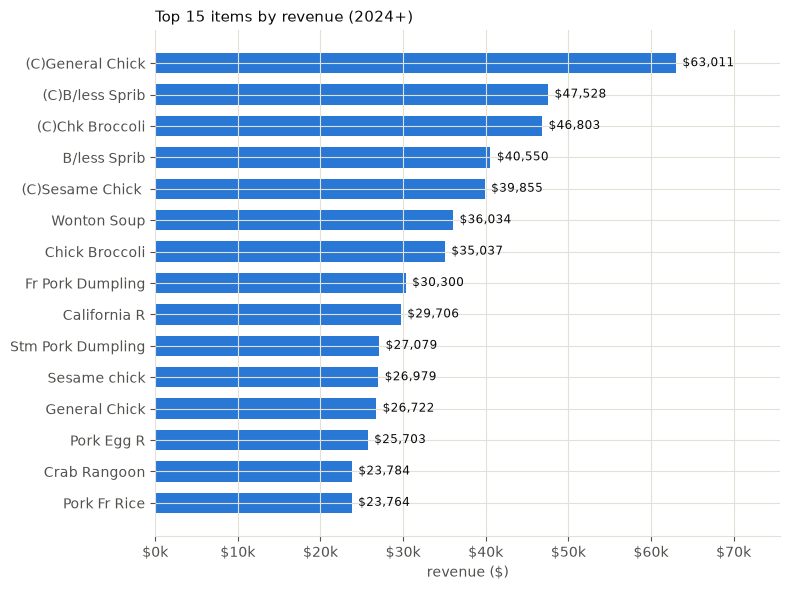

In [18]:
top15 = item_stats.sort_values("revenue", ascending=False).head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top15["dish_name"], top15["revenue"], color=BLUE, height=0.65)
for bar, value in zip(bars, top15["revenue"]):
    ax.text(value + 800, bar.get_y() + bar.get_height() / 2, f"${value:,.0f}",
            va="center", ha="left", fontsize=8.5, color="#0b0b0b")

ax.set_xlabel("revenue ($)")
ax.set_xlim(0, top15["revenue"].max() * 1.2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v/1000:.0f}k"))
ax.set_title("Top 15 items by revenue (2024+)", loc="left", fontsize=11)
plt.tight_layout()
plt.show()


### Revenue concentration / long-tail curve

This makes the Step 5a finding visible: items ranked from most- to least-ordered on the x-axis, cumulative share of total revenue on the y-axis. A steep rise on the left with a long, flat tail on the right is the visual signature of "a small number of items carry the business, and a long tail contributes almost nothing."


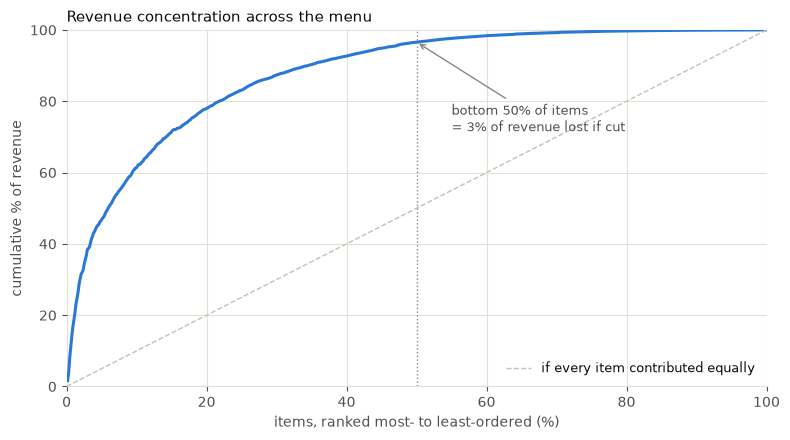

In [19]:
ranked = item_stats.sort_values("times_ordered", ascending=False).reset_index(drop=True)
ranked["cum_revenue_pct"] = 100 * ranked["revenue"].cumsum() / ranked["revenue"].sum()
ranked["item_rank_pct"] = 100 * (ranked.index + 1) / len(ranked)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(ranked["item_rank_pct"], ranked["cum_revenue_pct"], color=BLUE, linewidth=2.2)
ax.plot([0, 100], [0, 100], color=GRAY_BASELINE, linestyle="--", linewidth=1, label="if every item contributed equally")

ax.axvline(50, color=GRAY_MUTED, linestyle=":", linewidth=1)
halfway_revenue = ranked.loc[ranked["item_rank_pct"].sub(50).abs().idxmin(), "cum_revenue_pct"]
ax.annotate(f"bottom 50% of items\n= {100 - halfway_revenue:.0f}% of revenue lost if cut",
            xy=(50, halfway_revenue), xytext=(55, halfway_revenue - 25),
            fontsize=9, color=TEXT_SECONDARY,
            arrowprops=dict(arrowstyle="->", color=GRAY_MUTED, lw=1))

ax.set_xlabel("items, ranked most- to least-ordered (%)")
ax.set_ylabel("cumulative % of revenue")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_title("Revenue concentration across the menu", loc="left", fontsize=11)
ax.legend(frameon=False, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()


## Summary

**Data note:** 674 distinct menu items, 2024+, after excluding non-dish line items (combo-selection placeholders, service charges, paid add-ons — 2.7% of gross line revenue) and applying notebook 01's order-level cleaning.

### Cut candidates
- **The bottom half of the menu by order count (337 items) generates only 3.4% of total revenue** — a median of 9 orders across ~2.5 years. This is the single strongest simplification signal in the data: trimming even a large share of this tail costs very little measured revenue. (Caveat: this data can't see whether a specific low-volume item is a beloved regular's standing order — that's a judgment call this notebook can't make.)
- **"Chinese Lunch" (87 items, 2.1% of revenue) is the most bloated single category** — the most items of any category by a wide margin, for one of the smallest revenue shares. Likely lower-priced lunch duplicates of dishes that already exist on the dinner menu.
- **Within protein-variant families, the losing sibling is usually pork, tofu, beef, or shrimp — never consistently one of them, but chicken wins outright 66% of the time.** Any family where a non-chicken variant is capturing under 20% of that family's orders (flagged explicitly in Step 5b) is a concrete, name-level candidate for trimming — e.g. tofu and pork versions of the "Broccoli" combo captured a combined 8% of that family's orders, versus 92% for beef and shrimp.

### Keep — high performers
- **The top 5 items by revenue are also top 5 by popularity** — `(C)General Chick`, `(C)B/less Sprib`, `(C)Chk Broccoli`, `B/less Sprib`, `(C)Sesame Chick` are unambiguous anchors, ordered thousands of times each with no ambiguity about their value.
- **`Combo` and `Chinese Combo` categories have the highest revenue-per-item** ($11,113 and $2,168 respectively) despite modest item counts (15 and 90) — efficient, high-performing menu real estate.
- **`Dumpling` and `App Sald Soup` (appetizers/salad/soup) also show strong revenue-per-item** alongside high order counts — broad, reliable categories worth protecting as-is.

### Other findings, purely descriptive
- The menu is **less combo-dependent than the top-revenue list alone suggests**: combo-format items dominate individual rankings, but only account for 23.3% of total menu-item revenue — the other 76.7% is spread across everyday à la carte ordering.
- **Margin proxy (estimate only, not real data):** of the 59% of revenue that could be tied to a protein keyword, chicken/pork/veg/tofu (presumed lower-cost) makes up 42.1% of total revenue, shrimp/seafood (presumed higher-cost) 13.3%, and beef — despite appearing in 64 items — only 3.8%, the smallest of the three tiers. 41% of revenue couldn't be classified at all (drinks, rice, generically-named combos, and sushi rolls not named after their fish), so treat this as a loose directional read, not a real margin conclusion.

**Everything above is descriptive, not a recommendation** — which items to actually cut, consolidate, or reprice is a call for Tang to make, informed by this data alongside things this notebook can't see (specific regulars' preferences, ingredient sourcing, kitchen prep complexity, seasonal items).


**74 protein-variant families detected, covering 321 of 674 items (48%) — nearly half the menu is built from repeated dish patterns across proteins.** The `(C) Broccoli` combo family above is a representative example: beef (51%) and shrimp (41%) combined take 92% of that family's orders, leaving pork (5.8%) and tofu (2.4%) far behind their siblings.

**Checking this systematically across all 74 families (not just eyeballing a few) tells a cleaner story than "pork and tofu lose":** chicken wins its family outright in 44 of 74 families (66%, counting both "chick" and "chicken" spellings) — by far the single most consistent winner. Every other protein — beef, pork, shrimp, tofu, vegetable — shows up as the underperforming sibling (under 20% of its family's orders) in roughly similar numbers to each other, without one standing out as uniquely weak. **The real, repeated signal here is "chicken wins," not "pork and tofu specifically lose."**
